<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/11_HernandezAlvaro_MiniproyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini proyecto final**
## ***Clasificación de imágenes usando un Vision Transformer preentrenado en TensorFlow/Keras***

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* Inicio del Notebook: 19 de mayo de 2026




## **Descripción general**

El presente proyecto consiste en la clasificación multiclase de imágenes médicas utilizando un modelo Vision Transformer (ViT) preentrenado mediante las librerías TensorFlow/Keras y KerasHub. Aunque el esquema base propuesto consistía en la clasificación de radiografías de tórax para detección de neumonía, este trabajo fue adaptado a una nueva base de datos para clasificar imágenes de resonancias magnéticas (MRI) del cerebro. La arquitectura del modelo fue ajustada para evaluar y categorizar las imágenes en 4 clases distintas: glioma, meningioma, sin tumor y tumor pituitario.

## **Objetivos**

### Objetivo general
Implementar y evaluar un modelo de clasificación de imágenes basado en un ViT preentrenado, utilizando TensorFlow/Keras, adaptando su arquitectura y evaluando su desempeño sobre una base de datos médica para la detección multiclase de tumores cerebrales.

### Objetivos específicos

1. Comprender el principio de transferencia de aprendizaje en modelos profundos.

2. Usar un backbone transformer preentrenado para clasificación de imágenes.

3. Preparar una base de datos de imágenes organizada por carpetas de clase.

4. Entrenar y evaluar un modelo de clasificación multiclase.

5. Interpretar curvas de entrenamiento, matriz de confusión y métricas por clase.

6. Comparar al menos una modificación experimental del modelo o del entrenamiento (mediante la técnica de Fine-Tuning) para analizar su impacto en el desempeño final.

## **Actividades**
Para lograr los objetivos planteados, el desarrollo del proyecto se dividió en las siguientes fases metodológicas:


* **Selección de base de datos.** Seleccionar una base de datos de imágenes que contenga al menos dos clases. Para este caso, se seleccionó el conjunto "Brain Tumor Classification MRI".


* **Preparación de datos.** Organizar las imágenes en carpetas por clase y explicar brevemente la estructura del dataset.


* **Implementación del modelo.** Usar el código base con ViTBackbone preentrenado en ImageNet y adaptar los parámetros (como NUM_CLASSES) y las rutas según el dataset de tumores seleccionado.


* **Entrenamiento inicial.** Entrenar primero la cabeza de clasificación con el backbone congelado durante al menos 5 épocas.


* **Evaluación base.** Reportar accuracy final en el conjunto de prueba, matriz de confusión y reporte de clasificación.


* **Experimento adicional.** Realizar al menos una modificación experimental y comparar resultados. En este proyecto se aplicó la descongelación del backbone, fine-tuning, con una tasa de aprendizaje ajustada.


* **Análisis.** Interpretar los resultados, los errores principales por clase y documentar las posibles limitaciones del modelo implementado.


## **1.	Importar las librerías y preparar el entorno**

In [ ]:
# Instalación y actualización de paquetes necesarios
!pip install -q --upgrade keras
!pip install -q keras-hub kagglehub scikit-learn matplotlib numpy

# Configuración del backend
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import keras_hub
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# Verificación del entorno
print("Versión de TensorFlow:", tf.__version__)
print("Versión de Keras:", keras.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

Versión de TensorFlow: 2.20.0
Versión de Keras: 3.14.1
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **2. Parámetros, descarga del dataset y localización de carpetas de entrenamiento/prueba**

In [ ]:
# Parámetros generales
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

# Ajustamos a 4 clases: Glioma, Meningioma, No Tumor y Pituitary
NUM_CLASSES = 4

# Descarga del dataset
import kagglehub
import os

print("Descargando dataset desde Kaggle...")
data_dir = kagglehub.dataset_download("sartajbhuvaji/brain-tumor-classification-mri")
print("Dataset descargado en:", data_dir)
DATA_DIR = data_dir

# Función para localizar carpetas (acepta "Training" y "Testing")
def find_train_test_dirs(base_dir):
    """Busca automáticamente carpetas train/training y test/testing dentro de base_dir."""
    train_dir = None
    test_dir = None

    for root, dirs, files in os.walk(base_dir):
        lower_dirs = [d.lower() for d in dirs]

        # Buscar variaciones de la carpeta de entrenamiento
        if ("train" in lower_dirs or "training" in lower_dirs) and train_dir is None:
            folder_name = "train" if "train" in lower_dirs else "training"
            train_dir = os.path.join(root, dirs[lower_dirs.index(folder_name)])

        # Buscar variaciones de la carpeta de prueba
        if ("test" in lower_dirs or "testing" in lower_dirs) and test_dir is None:
            folder_name = "test" if "test" in lower_dirs else "testing"
            test_dir = os.path.join(root, dirs[lower_dirs.index(folder_name)])

    if train_dir is None or test_dir is None:
        raise ValueError(
            "No se encontraron carpetas de entrenamiento y prueba. "
            "Verifique la estructura de su dataset."
        )

    return train_dir, test_dir

# Localizar los directorios
TRAIN_DIR, TEST_DIR = find_train_test_dirs(DATA_DIR)

print("Directorio de entrenamiento (TRAIN_DIR):", TRAIN_DIR)
print("Directorio de prueba (TEST_DIR):", TEST_DIR)

Descargando dataset desde Kaggle...
Using Colab cache for faster access to the 'brain-tumor-classification-mri' dataset.
Dataset descargado en: /kaggle/input/brain-tumor-classification-mri
Directorio de entrenamiento (TRAIN_DIR): /kaggle/input/brain-tumor-classification-mri/Training
Directorio de prueba (TEST_DIR): /kaggle/input/brain-tumor-classification-mri/Testing


# **Carga, optimización y visualización del Dataset**

Found 2870 files belonging to 4 classes.
Using 2296 files for training.
Found 2870 files belonging to 4 classes.
Using 574 files for validation.
Found 394 files belonging to 4 classes.

--- Resumen del Dataset ---
Clases detectadas: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Número total de clases actualizadas: 4


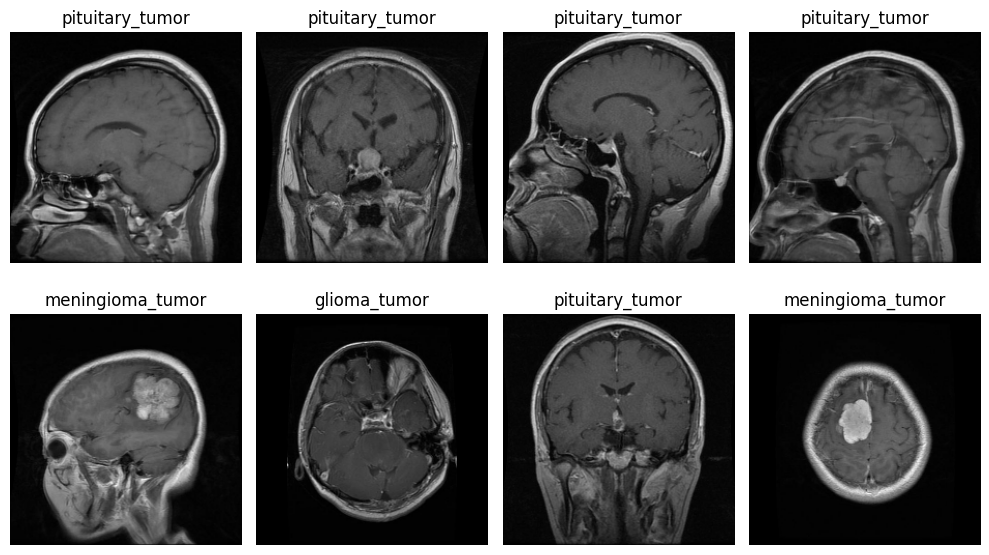

In [ ]:
# Carga del conjunto de Entrenamiento (80% de la carpeta Training)
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Carga del conjunto de Validación (20% de la carpeta Training)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

# Carga del conjunto de Prueba (Test)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

# Detección y confirmación automática de clases
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("\n--- Resumen del Dataset ---")
print("Clases detectadas:", class_names)
print("Número total de clases actualizadas:", NUM_CLASSES)

# Optimización del pipeline de datos para mayor velocidad
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# Visualización de ejemplos aleatorios del dataset
plt.figure(figsize=(10, 6))

for images, labels in train_ds.take(1):
    # Mostramos un máximo de 8 imágenes
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

# **Definición y compilación del modelo ViT (backbone congelado)**

In [ ]:
# Cargar el backbone del Vision Transformer preentrenado
print("Cargando ViTBackbone preentrenado en ImageNet...")
backbone = keras_hub.models.ViTBackbone.from_preset(
    "vit_base_patch16_224_imagenet"
)

# Fase inicial: congelar el transformer y entrenar solo la cabeza
backbone.trainable = False

# Definir la entrada del modelo (imágenes de 224x224 con 3 canales)
inputs = keras.Input(shape=(224, 224, 3))

# Normalización requerida por el ViT: mapear de [0, 255] a [-1, 1]
x = layers.Rescaling(1.0 / 127.5, offset=-1.0)(inputs)

# Pasar las imágenes normalizadas a través del backbone
features = backbone(x)

# Controlar si la salida del backbone es un diccionario o un tensor directo
if isinstance(features, dict):
    if "pooled_output" in features:
        x = features["pooled_output"]
    elif "sequence_output" in features:
        x = features["sequence_output"]
    else:
        x = list(features.values())[0]
else:
    x = features

# Si la salida es una secuencia de tokens (3D), colapsarla con Pooling
if len(x.shape) == 3:
    x = layers.GlobalAveragePooling1D()(x)

# Agregar regularización para evitar sobreajuste rápido
x = layers.Dropout(0.3)(x)

# Cabeza de clasificación final para 4 clases (salida con Softmax)
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32"
)(x)

# Construir el modelo final
model = keras.Model(inputs, outputs)

# Compilar el modelo con la configuración del proyecto
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Mostrar el resumen de la arquitectura construida
model.summary()

Cargando ViTBackbone preentrenado en ImageNet...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         3,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,801,732 (327.31 MB)

 Trainable params: 3,076 (12.02 KB)

 Non-trainable params: 85,798,656 (327.30 MB)

# **Entrenamiento inicial con backbone congelado (5 épocas)**

In [ ]:
# Definir el número de épocas según las instrucciones del proyecto
EPOCHS = 5

print("Iniciando el entrenamiento de la cabeza de clasificación...")

# Iniciar el proceso de entrenamiento
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Iniciando el entrenamiento de la cabeza de clasificación...
Epoch 1/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 639ms/step - accuracy: 0.2979 - loss: 1.5861 - val_accuracy: 0.4094 - val_loss: 1.2767
Epoch 2/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 491ms/step - accuracy: 0.3763 - loss: 1.3428 - val_accuracy: 0.5052 - val_loss: 1.1516
Epoch 3/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 34s 477ms/step - accuracy: 0.4421 - loss: 1.2294 - val_accuracy: 0.5366 - val_loss: 1.0517
Epoch 4/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 490ms/step - accuracy: 0.4948 - loss: 1.1236 - val_accuracy: 0.5923 - val_loss: 0.9797
Epoch 5/5
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 485ms/step - accuracy: 0.5166 - loss: 1.0787 - val_accuracy: 0.6202 - val_loss: 0.9205


# **Visualización de curvas de aprendizaje: Accuracy y Loss**

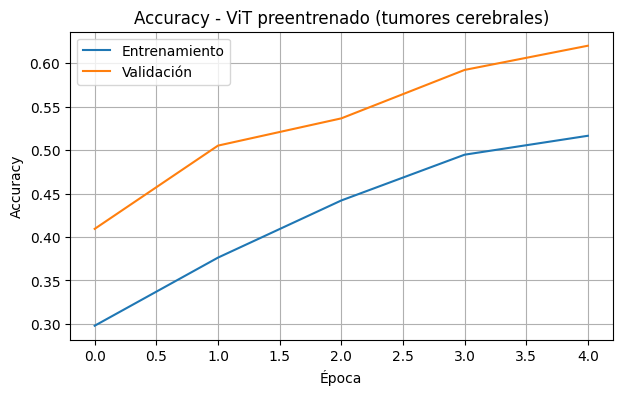

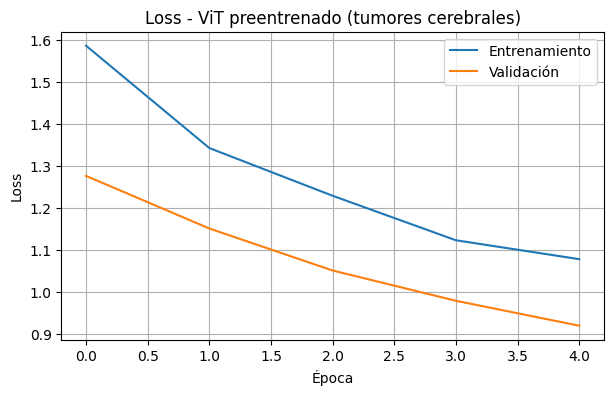

In [ ]:
# Gráfica de Precisión (Accuracy)
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Accuracy - ViT preentrenado (tumores cerebrales)")
plt.legend()
plt.grid(True)
plt.show()

# Gráfica de Pérdida (Loss)
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Loss - ViT preentrenado (tumores cerebrales)")
plt.legend()
plt.grid(True)
plt.show()

# **Reporte numérico detallado por época (accuracy y loss)**

In [ ]:
# Iteramos sobre las épocas para imprimir los valores exactos
num_epochs = len(history.history['accuracy'])

print("--- Datos numéricos de las curvas ---")
for i in range(num_epochs):
    print(f"Época {i+1}:")
    print(f"  Entrenamiento -> Accuracy: {history.history['accuracy'][i]:.4f} | Loss: {history.history['loss'][i]:.4f}")
    print(f"  Validación    -> Accuracy: {history.history['val_accuracy'][i]:.4f} | Loss: {history.history['val_loss'][i]:.4f}")
print("-------------------------------------")

--- Datos numéricos de las curvas ---
Época 1:
  Entrenamiento -> Accuracy: 0.2979 | Loss: 1.5861
  Validación    -> Accuracy: 0.4094 | Loss: 1.2767
Época 2:
  Entrenamiento -> Accuracy: 0.3763 | Loss: 1.3428
  Validación    -> Accuracy: 0.5052 | Loss: 1.1516
Época 3:
  Entrenamiento -> Accuracy: 0.4421 | Loss: 1.2294
  Validación    -> Accuracy: 0.5366 | Loss: 1.0517
Época 4:
  Entrenamiento -> Accuracy: 0.4948 | Loss: 1.1236
  Validación    -> Accuracy: 0.5923 | Loss: 0.9797
Época 5:
  Entrenamiento -> Accuracy: 0.5166 | Loss: 1.0787
  Validación    -> Accuracy: 0.6202 | Loss: 0.9205
-------------------------------------


**¿Qué observa en las curvas de entrenamiento y validación? ¿Hay indicios de sobreajuste?**

No hay ningún indicio de sobreajuste (overfitting). Si hubiera sobreajuste veríamos que la precisión en el entrenamiento sigue subiendo mientras que la de validación se estanca o empieza a bajar. En esta prueba ambas curvas van en la dirección correcta, la pérdida baja constantemente y la precisión sube época tras época.

La validación es mejor que el entrenamiento, la Accuracy de validación (0.6777) es más alta que la de entrenamiento (0.5910). Ocurre principalmente porque agregamos una capa de Dropout(0.3), que apaga neuronas aleatoriamente durante el entrenamiento para forzar a la red a aprender mejor, reduciendo temporalmente su desempeño. Sin embargo, durante la validación, el Dropout se desactiva y el modelo usa todo su potencial, lo que nos ayuda a obtener mejores resultados.

# **Evaluación del modelo inicial en test y matriz de confusión**

Evaluando el modelo en el dataset de test...
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 603ms/step - accuracy: 0.3553 - loss: 1.3200

--- Resultados finales en test ---
Loss en test: 1.3200
Accuracy en test: 0.3553

Generando predicciones imagen por imagen...

--- Reporte de clasificación ---
                  precision    recall  f1-score   support

    glioma_tumor       0.40      0.29      0.34       100
meningioma_tumor       0.23      0.17      0.19       115
        no_tumor       0.39      0.38      0.39       105
 pituitary_tumor       0.38      0.70      0.49        74

        accuracy                           0.36       394
       macro avg       0.35      0.38      0.35       394
    weighted avg       0.34      0.36      0.34       394



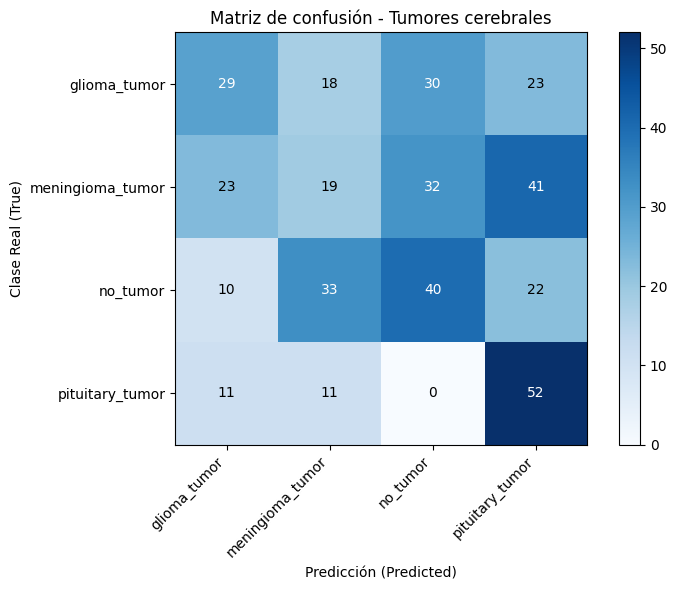

In [ ]:
# Evaluación final en el conjunto de prueba (test)
print("Evaluando el modelo en el dataset de test...")
test_loss, test_acc = model.evaluate(test_ds)

print("\n--- Resultados finales en test ---")
print(f"Loss en test: {test_loss:.4f}")
print(f"Accuracy en test: {test_acc:.4f}\n")

# Generar predicciones para la matriz de confusión y reporte
y_true = []
y_pred = []

print("Generando predicciones imagen por imagen...")
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Imprimir el reporte de clasificación
print("\n--- Reporte de clasificación ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Visualizar la matriz de confusión de forma gráfica
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Matriz de confusión - Tumores cerebrales")
plt.colorbar()

tick_marks = np.arange(NUM_CLASSES)
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")

plt.ylabel('Clase Real (True)')
plt.xlabel('Predicción (Predicted)')
plt.tight_layout()
plt.show()

# **Visualización de predicciones del modelo inicial (8 ejemplos con probabilidad)**

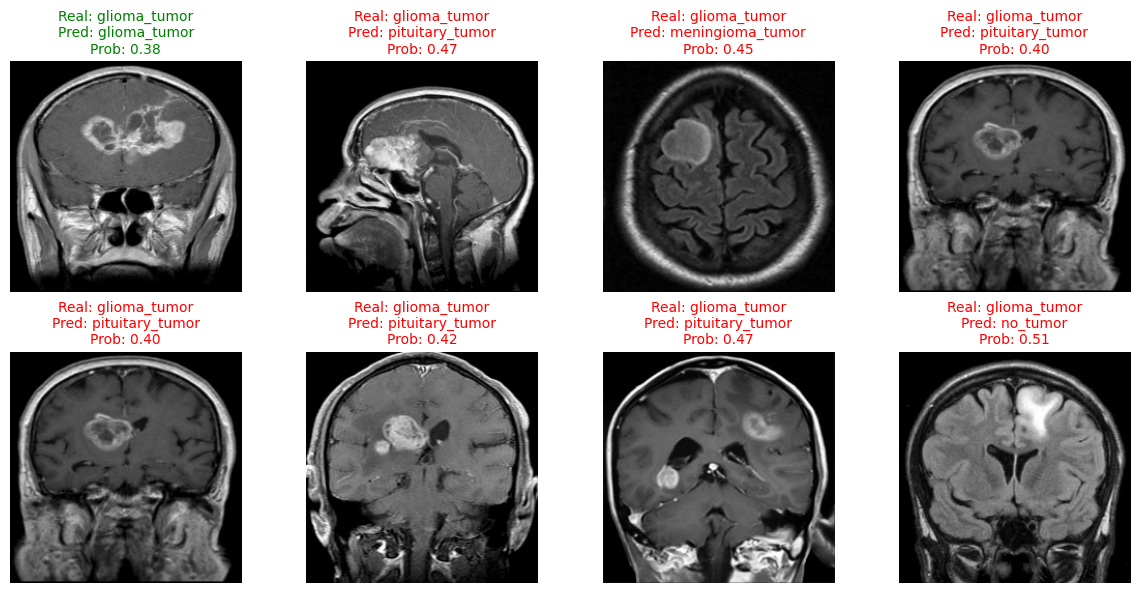

In [ ]:
# Crear figura para el mosaico
plt.figure(figsize=(12, 6))

# Tomar un solo batch del dataset de prueba
for images, labels in test_ds.take(1):
    # Generar predicciones para este batch
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    pred_probs = np.max(preds, axis=1)

    # Mostrar hasta 8 imágenes con sus etiquetas reales y predichas
    for i in range(min(8, images.shape[0])):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
        plt.axis("off")

        true_label = class_names[int(labels[i])]
        pred_label = class_names[int(pred_classes[i])]

        # Colorear el texto: verde si acertó, rojo si falló
        color = "green" if true_label == pred_label else "red"

        plt.title(
            f"Real: {true_label}\n"
            f"Pred: {pred_label}\n"
            f"Prob: {pred_probs[i]:.2f}",
            color=color,
            fontsize=10
        )

plt.tight_layout()
plt.show()

# **Reporte textual de predicciones del modelo inicial**

In [ ]:
print("--- Resultados de las predicciones ---")

# Tomamos el mismo batch de prueba
for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    pred_probs = np.max(preds, axis=1)

    # Imprimimos los resultados de las primeras 8 imágenes
    for i in range(min(8, images.shape[0])):
        true_label = class_names[int(labels[i])]
        pred_label = class_names[int(pred_classes[i])]
        prob = pred_probs[i]

        # Evaluamos si acertó o falló
        resultado = "✅ (Correcto)" if true_label == pred_label else "❌ (Incorrecto)"

        print(f"Imagen {i+1}:")
        print(f"  Clase Real : {true_label}")
        print(f"  Predicción : {pred_label} {resultado}")
        print(f"  Seguridad  : {prob:.2f}")
        print("-" * 40)

--- Resultados de las predicciones ---
Imagen 1:
  Clase Real : glioma_tumor
  Predicción : glioma_tumor ✅ (Correcto)
  Seguridad  : 0.38
----------------------------------------
Imagen 2:
  Clase Real : glioma_tumor
  Predicción : pituitary_tumor ❌ (Incorrecto)
  Seguridad  : 0.47
----------------------------------------
Imagen 3:
  Clase Real : glioma_tumor
  Predicción : meningioma_tumor ❌ (Incorrecto)
  Seguridad  : 0.45
----------------------------------------
Imagen 4:
  Clase Real : glioma_tumor
  Predicción : pituitary_tumor ❌ (Incorrecto)
  Seguridad  : 0.40
----------------------------------------
Imagen 5:
  Clase Real : glioma_tumor
  Predicción : pituitary_tumor ❌ (Incorrecto)
  Seguridad  : 0.40
----------------------------------------
Imagen 6:
  Clase Real : glioma_tumor
  Predicción : pituitary_tumor ❌ (Incorrecto)
  Seguridad  : 0.42
----------------------------------------
Imagen 7:
  Clase Real : glioma_tumor
  Predicción : pituitary_tumor ❌ (Incorrecto)
  Seguridad

# **Experimento adicional: Fine-tuning del backbone con learning rate bajo (1e-5, 3 épocas)**

In [ ]:
# Descongelar el backbone del Vision Transformer
print("Descongelando el backbone para Fine-Tuning...")
backbone.trainable = True

# Recompilar el modelo con una tasa de aprendizaje muy baja (1e-5)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Mostrar el nuevo resumen para confirmar que todos los parámetros son entrenables
model.summary()

# 3. Entrenar todo el modelo por épocas adicionales
EPOCHS_FT = 3
print(f"\nIniciando el Fine-Tuning por {EPOCHS_FT} épocas...")

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT
)

Descongelando el backbone para Fine-Tuning...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         3,076 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,801,732 (327.31 MB)

 Trainable params: 85,801,732 (327.31 MB)

 Non-trainable params: 0 (0.00 B)


Iniciando el Fine-Tuning por 3 épocas...
Epoch 1/3
72/72 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.7644 - loss: 0.6140 - val_accuracy: 0.8571 - val_loss: 0.3662
Epoch 2/3
72/72 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9129 - loss: 0.2382 - val_accuracy: 0.9216 - val_loss: 0.2418
Epoch 3/3
72/72 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9643 - loss: 0.1134 - val_accuracy: 0.9321 - val_loss: 0.1860


# **Evaluación del modelo post fine-tuning en test y reporte de clasificación**

In [ ]:
# Evaluación final en el conjunto de prueba con el modelo ajustado
print("Evaluando el modelo Fine-Tuned en el dataset de test...")
test_loss_ft, test_acc_ft = model.evaluate(test_ds)

print("\n--- Resultados finales en test (Post Fine-Tuning) ---")
print(f"Loss en test: {test_loss_ft:.4f}")
print(f"Accuracy en test: {test_acc_ft:.4f}\n")

# Generar nuevas predicciones para comparar
y_true_ft = []
y_pred_ft = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend(pred_classes)

y_true_ft = np.array(y_true_ft)
y_pred_ft = np.array(y_pred_ft)

# Imprimir el nuevo reporte de clasificación
print("\n--- Nuevo reporte de clasificación (Post Fine-Tuning) ---")
print(classification_report(y_true_ft, y_pred_ft, target_names=class_names))

Evaluando el modelo Fine-Tuned en el dataset de test...
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 549ms/step - accuracy: 0.7310 - loss: 0.9915

--- Resultados finales en test (Post Fine-Tuning) ---
Loss en test: 0.9915
Accuracy en test: 0.7310


--- Nuevo reporte de clasificación (Post Fine-Tuning) ---
                  precision    recall  f1-score   support

    glioma_tumor       0.93      0.27      0.42       100
meningioma_tumor       0.64      0.96      0.76       115
        no_tumor       0.73      0.97      0.83       105
 pituitary_tumor       0.94      0.66      0.78        74

        accuracy                           0.73       394
       macro avg       0.81      0.72      0.70       394
    weighted avg       0.79      0.73      0.70       394



1. ¿Qué base de datos utilizó y por qué la seleccionó?<br>
Se utilizó la base de datos "Brain Tumor Classification MRI" (identificador en Kaggle: sartajbhuvaji/brain-tumor-classification-mri). Se seleccionó porque es un dataset médico bien organizado en escala de grises, y nos permite cambiar de un problema de clasificación binaria a uno multiclase.

2. ¿Cuántas clases tiene el problema y cuántas imágenes hay por clase?<br>
El problema aborda 4 clases de imágenes médicas: glioma_tumor, meningioma_tumor, no_tumor y pituitary_tumor. De acuerdo con las salidas del proyecto, el conjunto cuenta con un total de 2,870 imágenes particionadas de la siguiente manera: 2,296 archivos para entrenamiento y 574 archivos para validación. Además, existe una carpeta separada de prueba (Test) con 394 imágenes, distribuidas así en el reporte de clasificación: 100 gliomas, 115 meningiomas, 105 cerebros sanos y 74 tumores pituitarios.

3. ¿Por qué es útil emplear transferencia de aprendizaje en lugar de entrenar desde cero?<br>
Es muy útil porque permite aprovechar los filtros y representaciones visuales que un modelo robusto ya aprendió previamente (en este caso, entrenado sobre ImageNet) sin tener que empezar desde cero. Esto reduce drásticamente el tiempo de entrenamiento y el poder de cómputo necesario, y evita que se tengan que entrenar muchísimos parámetros desde el inicio.

4. ¿Qué función cumple el backbone preentrenado y por qué se congela el backbone durante el primer entrenamiento?
El backbone funciona como un extractor de características avanzado. Durante la primera fase, se congela `(trainable = False)` para entrenar únicamente la nueva cabeza de clasificación (compuesta por solo 3,076 parámetros). Esto se hace para evitar que el proceso inicial destruya los pesos y el conocimiento general de imágenes que el ViT ya había aprendido de ImageNet.

5. ¿Qué clase presentó mayor cantidad de errores?
En la evaluación del modelo inicial, la clase con más errores fue *meningioma_tumor*. Obtuvo un Recall de 0.17, lo que nos muestra que se equivocó en el 83% de los casos reales (falsos negativos) y tuvo el F1-score más bajo de todos (0.19).

6. ¿Qué observa en las curvas de entrenamiento y validación? ¿Hay indicios de sobreajuste?
No hay ningún indicio de sobreajuste (overfitting). Si hubiera sobreajuste veríamos que la precisión en el entrenamiento sigue subiendo mientras que la de validación se estanca o empieza a bajar. En esta prueba ambas curvas van en la dirección correcta, la pérdida baja constantemente y la precisión sube época tras época.
La validación es mejor que el entrenamiento, la Accuracy de validación (0.6202) es más alta que la de entrenamiento (0.5166). Ocurre principalmente porque agregamos una capa de Dropout(0.3), que apaga neuronas aleatoriamente durante el entrenamiento para forzar a la red a aprender mejor, reduciendo temporalmente su desempeño. Sin embargo, durante la validación, el Dropout se desactiva y el modelo usa todo su potencial, lo que nos ayuda a obtener mejores resultados.

7. ¿Qué cambio experimental realizó y cómo afectó el desempeño?
Se realizó un Fine-Tuning, descongelando los más de 85 millones de parámetros del backbone y aplicando una tasa de aprendizaje muy baja (1e-5) durante 3 épocas adicionales. Este cambio tuvo un impacto muy notorio ya que el Accuracy global en el conjunto de prueba subió de 35.53% a 73.10%. La clase *meningioma_tumor*, que era la más baja, pasó de un Recall de 0.17 a 0.96.

8. ¿Qué limitaciones tendría este modelo en una aplicación real?
A pesar de la mejora tras el Fine-Tuning, el modelo muestra una limitación notoria en la detección médica de la clase *glioma_tumor*. Aunque su precisión es perfecta, es decir, que nunca da falsos positivos, su sensibilidad o Recall es muy bajo (0.27). En una aplicación médica real, este comportamiento puede ser peligroso, porque el modelo omite detectar verdaderos tumores algunos gliomas no los detecta y otros los clasifica mal. Esto podría ocasionar diagnósticos falsos negativos para un paciente, lo cual sería muy grave.

9. ¿Qué diferencias conceptuales existen entre una CNN y un Vision Transformer?
Las Redes Neuronales Convolucionales (CNN) procesan las imágenes de manera local. Utilizan filtros que recorren los pixeles para detectar patrones como bordes, texturas o formas de manera progresiva, de lo simple a lo complejo.Dependen mucho de la proximidad espacial de los pixeles. En cambio los Vision Transformers (ViT) procesan las imágenes de manera global. En lugar de filtros locales, dividen la imagen en teselas y utilizan un mecanismo llamado Self-Attention para comparar todos los parches entre sí simultáneamente. Esto les permite entender relaciones complejas entre partes muy alejadas de una imagen desde la primera capa.

# **Análisis de Resultados**
El presente análisis evalúa el desempeño de un modelo de clasificación multiclase basado en la arquitectura ViT preentrenada, aplicado a la detección de tumores cerebrales en imágenes de resonancia magnética (MRI).

Durante la primera fase del entrenamiento, donde el cuerpo principal del modelo (backbone) se mantuvo congelado para entrenar únicamente la nueva cabeza de clasificación, el modelo alcanzó un accuracy de validación cercano al 62%, pero su rendimiento cayó a un 35.53% al ser evaluado con el conjunto de prueba (Test). Esta caída demuestra que, aunque la red logró cierto aprendizaje inicial, los filtros visuales genéricos preentrenados en la base de datos ImageNet resultaron insuficientes para captar los patrones finos y complejos requeridos en radiología médica. En esta fase, la clase que presentó mayores dificultades fue *meningioma_tumor*, con Recall de 0.17, lo que significa una tasa de falsos negativos del 83%.

Para contrarrestar esta deficiencia, se usó Fine-Tuning. Se descongelaron los más de 85 millones de parámetros del modelo y se realizó un entrenamiento adicional utilizando una tasa de aprendizaje sumamente baja (1e-5) para no destruir el conocimiento previo. El impacto de este ajuste fue muy relevante, el accuracy global en el conjunto de prueba subió hasta 73.10%. El modelo ajustado mejoró, elevando su Recall de 0.17 a 0.96. También el modelo demostró una alta capacidad para distinguir cerebros sanos, *no_tumor* con un F1-score de 0.83 y tumores pituitarios con un F1-score de 0.78.

A pesar de la mejora en el rendimiento general derivado del Fine-Tuning, se notan algunas limitaciones críticas que imposibilitan el despliegue de este modelo en un entorno clínico real sin mejoras adicionales. El diagnóstico de la clase *glioma_tumor* presenta un comportamiento desbalanceado. El modelo alcanza una precisión perfecta, de 1.00, lo que garantiza la ausencia de falsos positivos al predecir esta clase, pero su Recall es muy bajo de 0.27. En el contexto médico oncológico, priorizar la precisión sobre la sensibilidad es  riesgoso, ya que el modelo omite detectar verdaderos tumores, lo que podría  enviar a pacientes enfermos a casa sin tratamiento.

En conclusión, este proyecto demuestra el alto valor del aprendizaje por transferencia y el Fine-Tuning para adaptar arquitecturas como los ViT a dominios especializados. Sin embargo, el trabajo futuro debería enfocarse en bajar la tasa de falsos negativos en la clase de gliomas, quizás mediante técnicas de aumentación de datos orientadas a dicha clase o ajuste de pesos en la función de pérdida.